<a href="https://colab.research.google.com/github/suri-pu-bi/mlops-for-backend/blob/main/1_CH02_01_PyTorch%EC%9D%98_%EA%B8%B0%EB%B3%B8_%EA%B5%AC%EC%A1%B0%EC%99%80_%ED%8A%B9%EC%A7%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 백엔드 개발자를 위한 MLOps
### 2.1 PyTorch의 기본 구조와 특징
Pytorch의 핵심 구성 요소와 프레임워크의 특징 설명.


In [2]:
import torch

In [3]:
# 스칼라
x = torch.tensor(5.0)
x

tensor(5.)

In [4]:
# 벡터
v = torch.tensor([1.0, 2.0, 3.0])
v

tensor([1., 2., 3.])

In [5]:
# 행렬
M = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
M

tensor([[1., 2.],
        [3., 4.]])

In [6]:
x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

# 덧셈
z1 = x + y
print(z1)

# 뺄셈
z2 = x - y
print(z2)

# 곱셈
z3 = x + y
print(z3)

# 나눗셈
z4 = x / y
print(z4)

tensor([5, 7, 9])
tensor([-3, -3, -3])
tensor([5, 7, 9])
tensor([0.2500, 0.4000, 0.5000])


### 2.2 PyTorch 기본 실습
PyTorch의 핵심 데이터 구조인 Tensor 조작 및 nn.Module 이해.


In [7]:
!pip install torchviz

  Preparing metadata (setup.py) ... done
  Created wheel for torchviz: filename=torchviz-0.0.2-py3-none-any.whl size=4132 sha256=df39bf985c176b246632912350881ac916686210746efc5bfae987696ef216ae
  Stored in directory: /root/.cache/pip/wheels/4c/97/88/a02973217949e0db0c9f4346d154085f4725f99c4f15a87094
Successfully built torchviz


In [8]:
from torchviz import make_dot
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [9]:
x = torch.tensor([1.0, 2.0, 3.0],requires_grad=True)
y = torch.tensor([4.0, 5.0, 6.0],requires_grad=True)

# 덧셈
z = x + y
print(z)

tensor([5., 7., 9.], grad_fn=<AddBackward0>)


In [10]:
z.grad_fn # x와 y로부터 뽑아졌다는 것 알 수 있음.

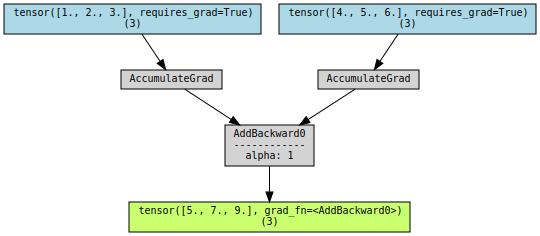

In [11]:
# Tensor들의 연관 관계 추적 가능
make_dot(z, params={x: x, y: y, z: z}, show_attrs=True, show_saved=True)

In [12]:
s = z.sum()

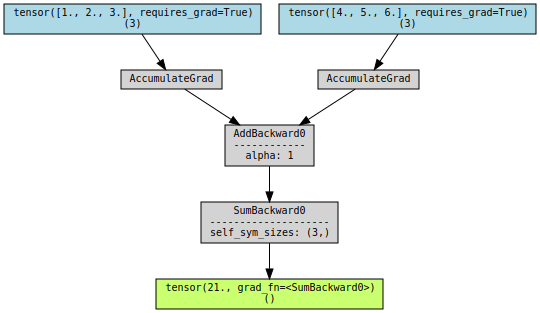

In [13]:
make_dot(s, params={x: x, y: y, z: z, s: s}, show_attrs=True, show_saved=True)

In [14]:
# Tensor의 연관 관계의 추적 과정들은(grad..) backward 연산을 할 때 사용.
s.backward()

예시1. 텐서 생성

In [15]:
# 0으로 채워진 텐서
x = torch.zeros(2, 3)
print(x)

# 1로 채워진 텐서
y = torch.ones(2, 3)
print(y)

# 특정 값을 기준으로 텐서 생성
z = torch.tensor([[1,2], [3,4]])
print(z)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[1, 2],
        [3, 4]])


예시2. 텐서 타입 및 크기 확인

In [16]:
x = torch.rand(2, 3, 4)
x

tensor([[[0.2469, 0.2825, 0.3053, 0.9299],
         [0.2557, 0.2224, 0.0834, 0.1007],
         [0.6160, 0.5783, 0.5948, 0.5615]],

        [[0.9518, 0.2237, 0.1070, 0.3939],
         [0.0547, 0.1998, 0.2796, 0.3597],
         [0.7153, 0.2822, 0.0731, 0.7268]]])

In [17]:
print(x.dtype)
print(x.size())

torch.float32
torch.Size([2, 3, 4])


예시3. 텐서 변환 (reshape)

In [18]:
x = torch.rand(4, 4) # 2차원 배열
x

tensor([[0.9003, 0.6822, 0.0816, 0.0627],
        [0.4137, 0.4245, 0.0750, 0.2617],
        [0.8549, 0.9437, 0.2647, 0.6352],
        [0.7437, 0.6597, 0.0348, 0.8602]])

In [19]:
y = x.view(16) # 4 * 4
y

tensor([0.9003, 0.6822, 0.0816, 0.0627, 0.4137, 0.4245, 0.0750, 0.2617, 0.8549,
        0.9437, 0.2647, 0.6352, 0.7437, 0.6597, 0.0348, 0.8602])

In [20]:
z = x.view(-1, 8) # -1은 차원을 추론하여 자동 계산한다는 의미 : 8개씩 담을 수 있도록
z

tensor([[0.9003, 0.6822, 0.0816, 0.0627, 0.4137, 0.4245, 0.0750, 0.2617],
        [0.8549, 0.9437, 0.2647, 0.6352, 0.7437, 0.6597, 0.0348, 0.8602]])

In [21]:
print(y.size())
print(z.size())

torch.Size([16])
torch.Size([2, 8])


예시4. 텐서 연결 (concatenation)

In [22]:
a = torch.tensor([[1, 2], [3, 4]]) # 2 * 2
b = torch.tensor([[5, 6]]) # 1 * 1
d = torch.tensor([[5], [6]])
c = torch.cat([a, b], dim = 0) # dim=0은 행을 기준으로 병합
z = torch.cat([a, d], dim = 1) # dim=1은 열을 기준으로 병합
print(c)
print(z)
print(c.size())
print(z.size())

tensor([[1, 2],
        [3, 4],
        [5, 6]])
tensor([[1, 2, 5],
        [3, 4, 6]])
torch.Size([3, 2])
torch.Size([2, 3])


예시5. 차원 추가 및 제거

In [23]:
x = torch.tensor([1, 2, 3, 4]) # 벡터
x1 = x.unsqueeze(0) # 차원 추가
x2 = x1.squeeze(0) # 차원 제거
print(x1)
print(x1.size())
print(x2)
print(x2.size())

tensor([[1, 2, 3, 4]])
torch.Size([1, 4])
tensor([1, 2, 3, 4])
torch.Size([4])


예시6. 텐서 인덱싱 및 슬라이싱

In [24]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(x) # 텐서 원본
print(x[0, :]) # 첫 번째 행 전체
print(x[:, 1]) # 두 번째 열 전체
print(x[1:, 1:]) # 첫 번째 행 이후의 각 행의, 첫 번째 열 이후의 각 열

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
tensor([1, 2, 3])
tensor([2, 5, 8])
tensor([[5, 6],
        [8, 9]])


예시7. 텐서 분리 (splitting)

In [25]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
a, b = torch.split(x, 2, dim=0) # 행 기준으로, 2개씩 분리
print(x) # 텐서 원본
print(a)
print(b)

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[ 7,  8,  9],
        [10, 11, 12]])


예시8. 텐서 전치 (transpose)

In [26]:
x = torch.tensor([[1, 2], [3, 4], [5, 6]])
print(x)
print(x.transpose(0, 1)) # 0번째와 1번째 자원을 전치

tensor([[1, 2],
        [3, 4],
        [5, 6]])
tensor([[1, 3, 5],
        [2, 4, 6]])


## nn.Module

`nn.Module`은 PyTorch의 신경망 구성을 위한 레이어 혹은 모델을 위한 클래스

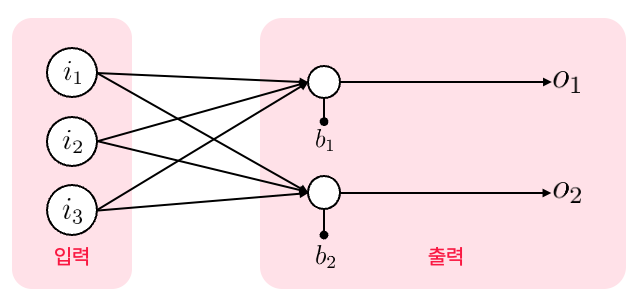

In [32]:
help(nn.Module)

Help on class Module in module torch.nn.modules.module:

class Module(builtins.object)
 |  Module(*args, **kwargs) -> None
 |  
 |  Base class for all neural network modules.
 |  
 |  Your models should also subclass this class.
 |  
 |  Modules can also contain other Modules, allowing to nest them in
 |  a tree structure. You can assign the submodules as regular attributes::
 |  
 |      import torch.nn as nn
 |      import torch.nn.functional as F
 |  
 |      class Model(nn.Module):
 |          def __init__(self) -> None:
 |              super().__init__()
 |              self.conv1 = nn.Conv2d(1, 20, 5)
 |              self.conv2 = nn.Conv2d(20, 20, 5)
 |  
 |          def forward(self, x):
 |              x = F.relu(self.conv1(x))
 |              return F.relu(self.conv2(x))
 |  
 |  Submodules assigned in this way will be registered, and will have their
 |  parameters converted too when you call :meth:`to`, etc.
 |  
 |  .. note::
 |      As per the example above, an ``__init__()

In [36]:
# nn.Module를 상속받는 클래스
class LinearModule(nn.Module):
  def __init__(self, input_dim, output_dim):
    super().__init__() # 부모 클래스의 초기화 메서드 호출
    self.fc = nn.Linear(input_dim, output_dim)

  def forward(self, x):
    return self.fc(x)

In [37]:
model = LinearModule(3, 2)
x = torch.randn(10, 3)
output = model(x)
output

tensor([[-0.0512, -0.1182],
        [ 0.0534, -0.5271],
        [-0.0297,  0.4630],
        [-0.1235,  0.7628],
        [-0.2251, -0.7146],
        [-0.0653,  0.6393],
        [-0.1907, -1.1223],
        [-0.0175, -0.1962],
        [ 0.1113, -0.1354],
        [ 0.2964,  0.3686]], grad_fn=<AddmmBackward0>)

## 실습: XOR 예측 문제

XOR 게이트 입력 매개변수 A, B를 주었을 때 출력 Y(A⊕B)를 계산하는 모델을 학습 및 구성.

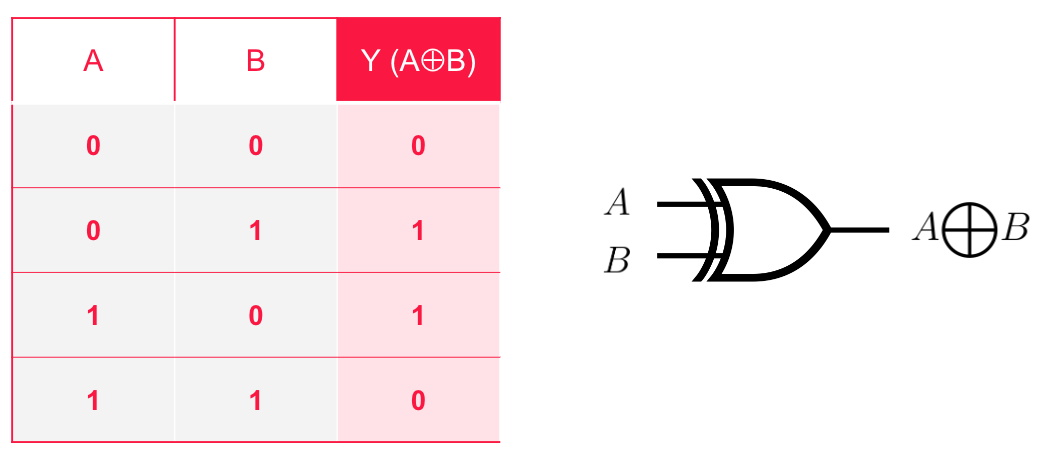

In [55]:
# XOR 연산을 위한 신경망 모델 정의
class XORModel(nn.Module):
  def __init__(self):
    super(XORModel, self).__init__()
    self.layer1 = nn.Linear(2, 2) # 입력 2개, 출력 2개
    self.layer2 = nn.Linear(2, 1) # 입력 2개, 출력 1개
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.sigmoid(self.layer1(x))
    x = self.sigmoid(self.layer2(x))
    return x

In [56]:
# 데이터 정의
x_data = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
# 입력 데이터에 대한 정답 데이터
y_data = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

# 모델 초기화
model = XORModel()

# 손실 함수 및 최적화 알고리즘 정의
criterion = nn.BCELoss() # Binary Cross-Entropy loss
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [57]:
# 모델 학습
losses = []
for epoch in range(100001):
  # Forward pass
  outputs = model(x_data)
  loss = criterion(outputs, y_data)

  # Backward pass and Optimization
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  losses.append(loss.item())

  if epoch % 1000 == 0:
    print(f'Epoch [{epoch}/10000], Loss: {loss.item():.4f}')

Epoch [0/10000], Loss: 0.7421
Epoch [1000/10000], Loss: 0.6931
Epoch [2000/10000], Loss: 0.6930
Epoch [3000/10000], Loss: 0.6930
Epoch [4000/10000], Loss: 0.6929
Epoch [5000/10000], Loss: 0.6928
Epoch [6000/10000], Loss: 0.6926
Epoch [7000/10000], Loss: 0.6922
Epoch [8000/10000], Loss: 0.6914
Epoch [9000/10000], Loss: 0.6892
Epoch [10000/10000], Loss: 0.6816
Epoch [11000/10000], Loss: 0.6544
Epoch [12000/10000], Loss: 0.5913
Epoch [13000/10000], Loss: 0.3000
Epoch [14000/10000], Loss: 0.0989
Epoch [15000/10000], Loss: 0.0541
Epoch [16000/10000], Loss: 0.0365
Epoch [17000/10000], Loss: 0.0273
Epoch [18000/10000], Loss: 0.0216
Epoch [19000/10000], Loss: 0.0179
Epoch [20000/10000], Loss: 0.0152
Epoch [21000/10000], Loss: 0.0132
Epoch [22000/10000], Loss: 0.0117
Epoch [23000/10000], Loss: 0.0105
Epoch [24000/10000], Loss: 0.0095
Epoch [25000/10000], Loss: 0.0086
Epoch [26000/10000], Loss: 0.0079
Epoch [27000/10000], Loss: 0.0073
Epoch [28000/10000], Loss: 0.0068
Epoch [29000/10000], Loss: 

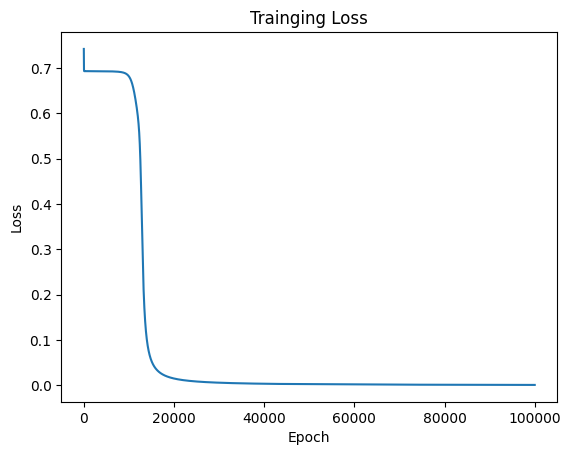

In [58]:
# Loss 시각화
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Trainging Loss')
plt.show()

In [63]:
# 모델 테스트
with torch.no_grad():
  test = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
  predicted = model(test)
  print(predicted)

tensor([[9.5184e-04],
        [9.9901e-01],
        [9.9901e-01],
        [1.4797e-03]])


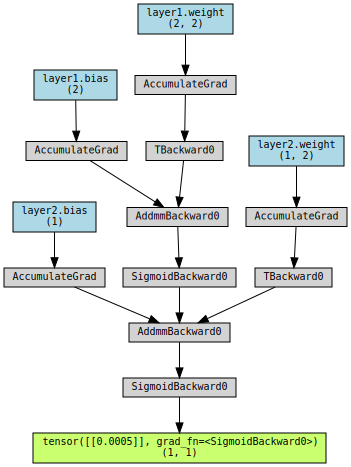

In [64]:
x = torch.randn(1, 2)
y = model(x)
make_dot(y, params={**dict(model.named_parameters()), y: y})